Activation Function

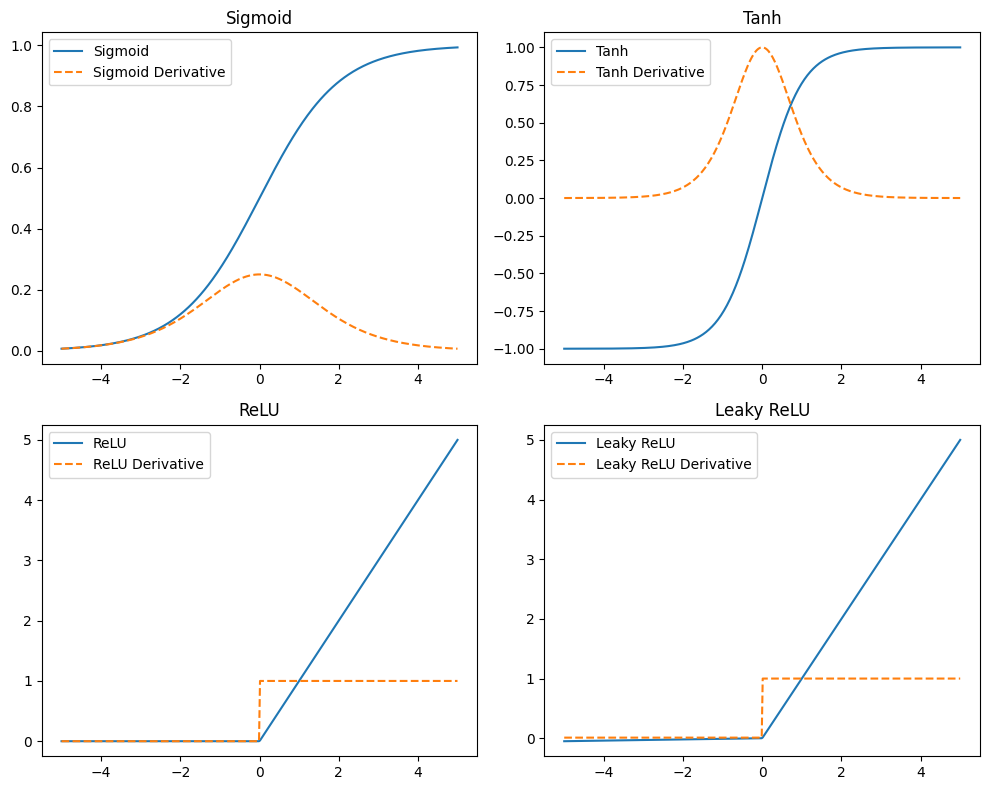

In [4]:
# Experiment 1: Implement and visualize activation functions
import numpy as np
import matplotlib.pyplot as plt

# Define activations and derivatives
def sigmoid(x): return 1 / (1 + np.exp(-x))
def dsigmoid(x): s = sigmoid(x); return s * (1 - s)

def tanh(x): return np.tanh(x)
def dtanh(x): return 1 - np.tanh(x) ** 2

def relu(x): return np.maximum(0, x)
def drelu(x): return (x > 0).astype(float)

def leaky_relu(x, a=0.01): return np.where(x > 0, x, a * x)
def dleaky_relu(x, a=0.01): return np.where(x > 0, 1, a)

x = np.linspace(-5, 5, 400)

# Plot each activation and derivative
funcs = [
    ("Sigmoid", sigmoid, dsigmoid),
    ("Tanh", tanh, dtanh),
    ("ReLU", relu, drelu),
    ("Leaky ReLU", leaky_relu, dleaky_relu)
]

plt.figure(figsize=(10, 8))
for i, (name, f, df) in enumerate(funcs, 1):
    plt.subplot(2, 2, i)
    plt.plot(x, f(x), label=f'{name}')
    plt.plot(x, df(x), '--', label=f'{name} Derivative')
    plt.title(name)
    plt.legend()
plt.tight_layout()
plt.show()


Single-Layer Perceptron (Linearly Separable Data)

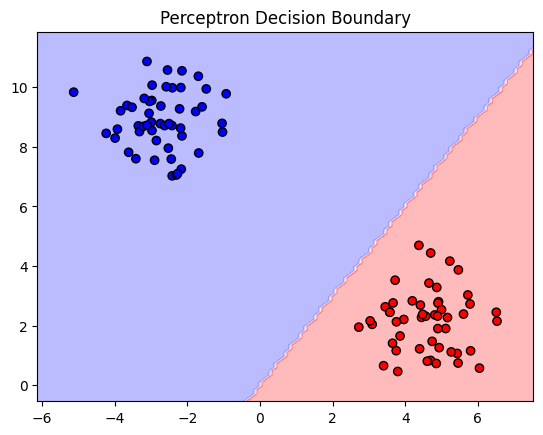

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Create linearly separable dataset
X, y = make_blobs(n_samples=100, centers=2, random_state=42)
y = np.where(y == 0, -1, 1)  # convert to -1, +1

# Initialize weights and bias
w = np.zeros(X.shape[1])
b = 0
lr = 0.1

# Perceptron learning
for epoch in range(20):
    for xi, target in zip(X, y):
        if target * (np.dot(w, xi) + b) <= 0:
            w += lr * target * xi
            b += lr * target

# Plot decision boundary
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = np.sign(np.dot(np.c_[xx.ravel(), yy.ravel()], w) + b)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.title("Perceptron Decision Boundary")
plt.show()


ANN with Backpropagation (from scratch)

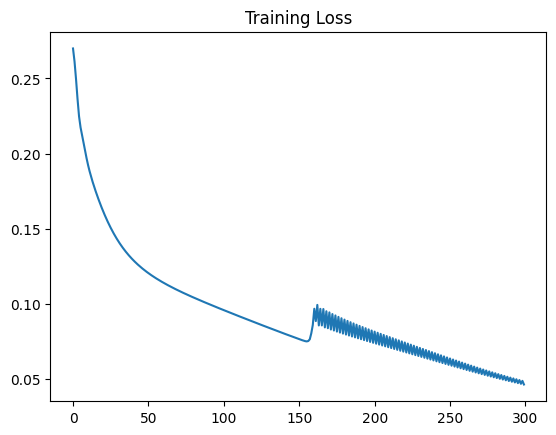

In [3]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)
enc = OneHotEncoder(sparse_output=False)
y = enc.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Activation
def sigmoid(x): return 1 / (1 + np.exp(-x))
def dsigmoid(x): s = sigmoid(x); return s * (1 - s)

# Initialize weights
np.random.seed(42)
W1 = np.random.randn(4, 8)
b1 = np.zeros((1, 8))
W2 = np.random.randn(8, 3)
b2 = np.zeros((1, 3))
lr = 0.01

losses = []
for epoch in range(300):
    # Forward
    z1 = X_train.dot(W1) + b1
    a1 = sigmoid(z1)
    z2 = a1.dot(W2) + b2
    y_hat = sigmoid(z2)

    # Loss (MSE)
    loss = np.mean((y_train - y_hat)**2)
    losses.append(loss)

    # Backprop
    dz2 = (y_hat - y_train) * dsigmoid(z2)
    dW2 = a1.T.dot(dz2)
    db2 = np.sum(dz2, axis=0, keepdims=True)

    dz1 = dz2.dot(W2.T) * dsigmoid(z1)
    dW1 = X_train.T.dot(dz1)
    db1 = np.sum(dz1, axis=0, keepdims=True)

    # Update
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

plt.plot(losses)
plt.title("Training Loss")
plt.show()


MLP with Keras (MNIST)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training with SGD optimizer...
Training with Adam optimizer...
Training with RMSprop optimizer...


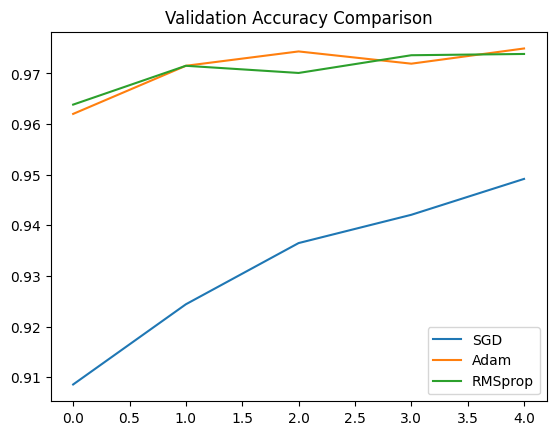

In [4]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

optimizers = {'SGD': SGD(), 'Adam': Adam(), 'RMSprop': RMSprop()}
history = {}

for name, opt in optimizers.items():
    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    print(f"Training with {name} optimizer...")
    hist = model.fit(x_train, y_train, epochs=5, validation_split=0.2, verbose=0)
    history[name] = hist

for name, hist in history.items():
    plt.plot(hist.history['val_accuracy'], label=f'{name}')
plt.legend(); plt.title('Validation Accuracy Comparison'); plt.show()


Basic Autoencoder (MNIST)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1100 - val_loss: 0.0417
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0382 - val_loss: 0.0291
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0277 - val_loss: 0.0232
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0224 - val_loss: 0.0192
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0188 - val_loss: 0.0165
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0162 - val_loss: 0.0145
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0144 - val_loss: 0.0131
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0132 - val_loss: 0.0121
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0123 - val_loss: 0.0115
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0117 - val_loss: 0.0110
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step


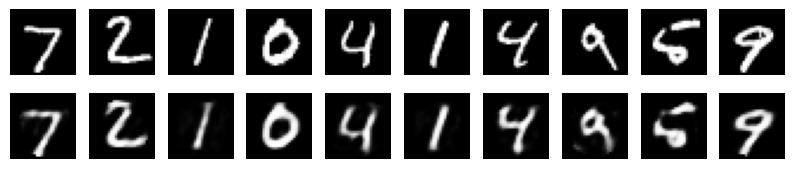

In [5]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), -1))
x_test = x_test.reshape((len(x_test), -1))

latent_dim = 32
input_img = Input(shape=(784,))
encoded = Dense(latent_dim, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(x_train, x_train, epochs=10, batch_size=256, validation_data=(x_test, x_test))

decoded_imgs = autoencoder.predict(x_test[:10])
plt.figure(figsize=(10,2))
for i in range(10):
    ax = plt.subplot(2,10,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    ax = plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.show()


Autoencoder for CIFAR-10

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - loss: 0.0243 - val_loss: 0.0076
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0073 - val_loss: 0.0064
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0063 - val_loss: 0.0060
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0059 - val_loss: 0.0055
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0055 - val_loss: 0.0053
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0053 - val_loss: 0.0051
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0050 - val_loss: 0.0048
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0048 - val_loss: 0.0046
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0045 - val_loss: 0.0043
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step


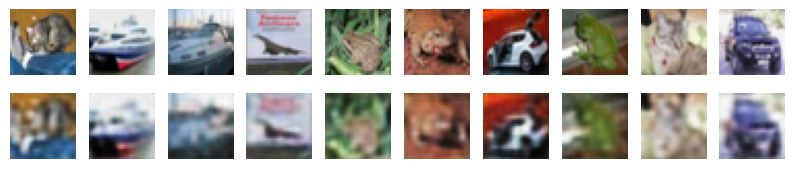

In [6]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

input_img = Input(shape=(32,32,3))
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(x_train, x_train, epochs=10, batch_size=128, validation_data=(x_test, x_test))

decoded_imgs = autoencoder.predict(x_test[:10])
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[i])
    plt.axis('off')
    plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i])
    plt.axis('off')
plt.show()
